In [4]:
#============================================
# 1. importaciones y configuraciones
#============================================

import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns

# configuración de estilo para gráficos
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10,6)
plt.rcParams['font.size'] = 11

# Semilla para reproducibilidad
np.random.seed(42)

# Para que pandas muestre todas las columnas
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

print("✅ Librerias cargadas correctamente")

✅ Librerias cargadas correctamente


In [5]:
#===================================
# 2. Carga de datos
#===================================

df = pd.read_csv("D:\\05 - Modelo Scoring Crediticion\\Codigo\\scoring_crediticio\\data\\raw\\scoring_crediticio.csv")

print("=" * 60)
print("✅ INFORMACIÓN GENERAL DEL DATASET")
print("=" * 60)
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
print(f"\nNombres de columnas:")
for col in df.columns:
    print(f"- {col}")

✅ INFORMACIÓN GENERAL DEL DATASET
Filas: 1000
Columnas: 12

Nombres de columnas:
- id_solicitud
- edad
- ciudad
- estrato
- ingreso_mensual
- antiguedad_laboral_meses
- num_creditos_activos
- utilizacion_cupo
- mora_maxima_12m
- num_consultas_6m
- dti
- default


In [6]:
#============================================
# 3. Primer vistazo a los datos
#============================================

print("🔍 Primeras 5 lineas:")
display(df.head())

print("\n🔍 Ultimas 5 lineas:")
display(df.tail())

print("\n🔍 Tipos de datos:")
display(df.dtypes)

print("\n🔍 Valores nulos por columnas:")
display(df.isnull().sum())

🔍 Primeras 5 lineas:


,id_solicitud,edad,ciudad,estrato,ingreso_mensual,antiguedad_laboral_meses,num_creditos_activos,utilizacion_cupo,mora_maxima_12m,num_consultas_6m,dti,default
0,SC-000000,35,Bogota,2,"1,000,000.00",128,2,0.35,60,5,0.30,0
1,SC-000001,28,Bogota,1,"1,118,000.00",278,2,0.31,30,2,0.16,0
2,SC-000002,37,Barranquilla,2,"2,023,000.00",61,1,0.12,0,2,0.14,0
3,SC-000003,48,Barranquilla,3,"1,000,000.00",16,5,0.28,0,4,0.75,1
4,SC-000004,27,Bogota,5,"1,000,000.00",101,3,0.06,150,1,0.33,0



🔍 Ultimas 5 lineas:


,id_solicitud,edad,ciudad,estrato,ingreso_mensual,antiguedad_laboral_meses,num_creditos_activos,utilizacion_cupo,mora_maxima_12m,num_consultas_6m,dti,default
995,SC-000995,26,Bogota,5,"1,415,000.00",45,0,0.16,0,1,0.00,0
996,SC-000996,51,Bogota,3,"3,922,000.00",86,3,0.48,90,4,0.22,0
997,SC-000997,37,Cali,4,"1,000,000.00",59,2,0.14,30,2,0.18,1
998,SC-000998,23,Bogota,6,"2,096,000.00",5,3,0.36,0,2,0.33,0
999,SC-000999,36,Bogota,1,"1,959,000.00",63,3,0.52,0,1,0.26,0



🔍 Tipos de datos:


id_solicitud                    str
edad                          int64
ciudad                          str
estrato                       int64
ingreso_mensual             float64
antiguedad_laboral_meses      int64
num_creditos_activos          int64
utilizacion_cupo            float64
mora_maxima_12m               int64
num_consultas_6m              int64
dti                         float64
default                       int64
dtype: object


🔍 Valores nulos por columnas:


id_solicitud                0
edad                        0
ciudad                      0
estrato                     0
ingreso_mensual             0
antiguedad_laboral_meses    0
num_creditos_activos        0
utilizacion_cupo            0
mora_maxima_12m             0
num_consultas_6m            0
dti                         0
default                     0
dtype: int64

In [7]:
#==============================================
# 4. Estadistica Descriptiva
#==============================================

print("📊 Estadistica de variables numéricas:")
display(df.describe().T) # .T = transpuesta para ver mejor

print("\n📊 Estadistica de variables categóricas:")
display(df.describe(include='object').T) # .T = transpuesta para ver mejor

#"""
#Que debemos observar en esta sección:
#- Los minimos y maximos son razonables?
#- Hay valores con media muy diferente a la mediana? (posibles outliers)
#- Cuantas categorias unicas hay en las variables de texto?
#- Hay valores nulos en las variables categóricas?
#"""

📊 Estadistica de variables numéricas:


,count,mean,std,min,25%,50%,75%,max
edad,"1,000.00",30.67,10.30,18.00,22.00,30.00,37.00,75.00
estrato,"1,000.00",3.48,1.43,1.00,3.00,3.00,4.00,6.00
ingreso_mensual,"1,000.00","1,374,785.00","678,819.81","1,000,000.00","1,000,000.00","1,000,000.00","1,488,250.00","10,384,000.00"
antiguedad_laboral_meses,"1,000.00",47.27,47.29,0.00,13.00,31.00,66.00,322.00
num_creditos_activos,"1,000.00",1.73,1.25,0.00,1.00,2.00,3.00,7.00
utilizacion_cupo,"1,000.00",0.28,0.16,0.01,0.16,0.25,0.38,0.82
mora_maxima_12m,"1,000.00",28.23,45.00,0.00,0.00,0.00,30.00,180.00
num_consultas_6m,"1,000.00",2.54,1.65,0.00,1.00,2.00,4.00,9.00
dti,"1,000.00",0.18,0.15,0.00,0.07,0.14,0.26,0.83
default,"1,000.00",0.30,0.46,0.00,0.00,0.00,1.00,1.00



📊 Estadistica de variables categóricas:


C:\Users\JF_PalenciaGallo\AppData\Local\Temp\ipykernel_22052\1883080328.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include='object').T) # .T = transpuesta para ver mejor


,count,unique,top,freq
id_solicitud,1000,1000,SC-000000,1
ciudad,1000,6,Bogota,296


<>:34: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
<>:34: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
C:\Users\JF_PalenciaGallo\AppData\Local\Temp\ipykernel_22052\3354051351.py:34: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
  plt.savefig('D:\05 - Modelo Scoring Crediticion\Codigo\scoring_crediticio\reports\01_target_distribution.png', dpi=100, bbox_inches='tight')


🎯 DISTRIBUCIÓN DEL TARGET (default)
Buenos pagadores (0): 699 (69.90%)
Malos pagadores (1): 301 (30.10%)

Ratio de desbalanceo: 1 malo por cada 2.3 buenos


C:\Users\JF_PalenciaGallo\AppData\Local\Temp\ipykernel_22052\3354051351.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='default', ax=axes[0], palette=['#2ecc71', '#e74c3c'])


OSError: [Errno 22] Invalid argument: 'D:\x05 - Modelo Scoring Crediticion\\Codigo\\scoring_crediticio\reports\x01_target_distribution.png'

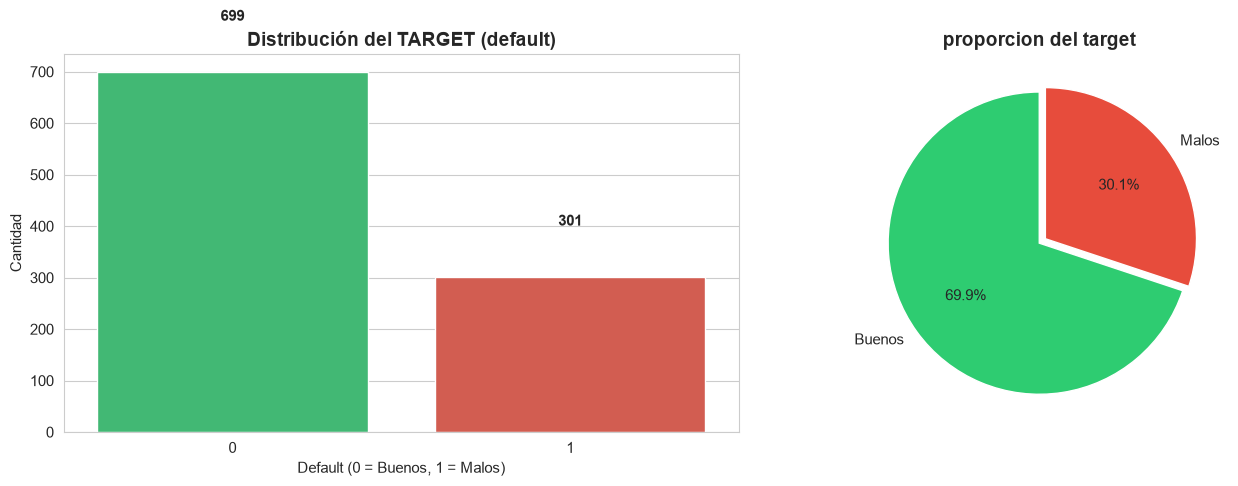

In [8]:
#===============================================
# 5. Análisis del TARGET (default)
#===============================================

# Distribución del TARGET (default)
target_counts = df['default'].value_counts()
target_pct = df['default'].value_counts(normalize=True) * 100

print("=" * 60)
print("🎯 DISTRIBUCIÓN DEL TARGET (default)")
print("=" * 60)
print(f"Buenos pagadores (0): {target_counts[0]:,} ({target_pct[0]:.2f}%)")
print(f"Malos pagadores (1): {target_counts[1]:,} ({target_pct[1]:.2f}%)")
print(f"\nRatio de desbalanceo: 1 malo por cada {target_counts[0] / target_counts[1]:.1f} buenos")

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras
sns.countplot(data=df, x='default', ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribución del TARGET (default)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Default (0 = Buenos, 1 = Malos)')
axes[0].set_ylabel('Cantidad')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

# Pie
axes[1].pie(target_counts.values, labels=['Buenos', 'Malos'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, explode=(0, 0.05))
axes[1].set_title('proporcion del target', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('D:\05 - Modelo Scoring Crediticion\Codigo\scoring_crediticio\reports\01_target_distribution.png', dpi=100, bbox_inches='tight')
plt.show()